# Stock Direction v11.1: Neural Trading Model with Stability Selection

This notebook keeps the small trading-oriented MLP setup from `v11`, but improves the input side:

- a richer catalog of transformations built from the existing engineered base dataset,
- stability-based feature selection across rolling time windows,
- asymmetric long/short thresholds,
- optional `long-only` mode inside the same search space.

The validation regime stays strict:

- rolling `12M train / 3M validation` for model selection,
- untouched final `6M` holdout for the last evaluation.


In [1]:
from itertools import product
from pathlib import Path
import ast
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

RANDOM_STATE = 42
FINAL_HOLDOUT_MONTHS = 6
TRAIN_MONTHS = 12
VAL_MONTHS = 3
STEP_MONTHS = 1
ONE_WAY_COST = 0.0005
MIN_STAGE2_SAMPLES = 30
MIN_ACTIVE_PCT = 0.08

MOVE_BANDS = [0.0075]
TOP_K_MOVE = [6, 8]
TOP_K_DIR = [6, 8]
HIDDEN_CHOICES = [(16,), (32, 16)]
ALPHA_VALUES = [0.001, 0.01]
LR_VALUES = [0.001]
MOVE_PROB_THRESHOLDS = [0.55, 0.60]
LONG_PROB_THRESHOLDS = [0.55, 0.60]
SHORT_PROB_THRESHOLDS = [0.45]
ALLOW_SHORT_CHOICES = [True, False]
STABILITY_TOP_N = 12

PRICE_FEATURES = [
    "ret_1d",
    "ret_2d",
    "ret_5d",
    "price_vs_sma_5d",
    "price_vs_sma_10d",
]
VOL_FEATURES = [
    "realized_vol_5d",
    "realized_vol_10d",
    "volume_z20",
    "volume_vs_sma_20d",
]
TREND_FEATURES = ["trends_change_7d"]
GDELT_FEATURES = ["gdelt_articles_z20", "gdelt_sentiment_score"]
SENTIMENT_FEATURES = ["subm_finbert_mean", "comm_finbert_mean"]
ACTIVITY_FEATURES = ["subm_posts_z20", "comm_posts_z20"]


In [2]:
def dedupe_keep_order(items):
    seen = set()
    ordered = []
    for item in items:
        if item not in seen:
            seen.add(item)
            ordered.append(item)
    return ordered


def add_feature_group(frame, source, base_cols, lags, mean_windows=(), delta_steps=()):
    created = []
    for col in base_cols:
        if col not in source.columns:
            continue
        series = source[col]
        frame[col] = series
        created.append(col)
        for lag in lags:
            name = f"{col}_lag{lag}"
            frame[name] = series.shift(lag)
            created.append(name)
        for window in mean_windows:
            name = f"{col}_mean{window}"
            frame[name] = series.rolling(window).mean()
            created.append(name)
        for step in delta_steps:
            name = f"{col}_delta{step}"
            frame[name] = series - series.shift(step)
            created.append(name)
    return created


def rank_features_mi(X_train, y_train):
    if X_train.empty:
        return pd.DataFrame(columns=["feature", "mi", "rank"])
    imp = SimpleImputer(strategy="median")
    X_i = imp.fit_transform(X_train)
    mi = mutual_info_classif(X_i, y_train.astype(int), random_state=RANDOM_STATE)
    ranked = pd.DataFrame({"feature": X_train.columns, "mi": mi}).sort_values(
        ["mi", "feature"], ascending=[False, True]
    ).reset_index(drop=True)
    ranked["rank"] = np.arange(1, len(ranked) + 1)
    return ranked


def fit_mlp(train_X, train_y, selected_cols, hidden_layers, alpha_value, learning_rate):
    model = Pipeline(
        steps=[
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
            (
                "clf",
                MLPClassifier(
                    hidden_layer_sizes=tuple(hidden_layers),
                    activation="relu",
                    solver="adam",
                    alpha=float(alpha_value),
                    learning_rate_init=float(learning_rate),
                    batch_size=32,
                    max_iter=500,
                    early_stopping=True,
                    n_iter_no_change=20,
                    validation_fraction=0.15,
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )
    model.fit(train_X[selected_cols], train_y)
    return model


def backtest_from_signals(future_returns, signals, one_way_cost):
    r = np.asarray(future_returns, dtype=float)
    s = np.asarray(signals, dtype=int)
    trade_mask = s != 0
    strat_ret = np.zeros(len(s), dtype=float)
    strat_ret[trade_mask] = s[trade_mask] * r[trade_mask] - 2.0 * one_way_cost
    true_dir = np.where(r > 0, 1.0, 0.0)
    return strat_ret, trade_mask, s, true_dir, int(trade_mask.sum())


def perf_stats(strat_ret, trade_mask, executed_signal, trades):
    strat_ret = np.asarray(strat_ret, dtype=float)
    trade_mask = np.asarray(trade_mask, dtype=bool)
    executed_signal = np.asarray(executed_signal, dtype=int)

    equity = np.cumprod(1 + strat_ret)
    running_max = np.maximum.accumulate(equity)
    drawdown = equity / running_max - 1

    hit_rate = np.nan
    if trade_mask.sum() > 0:
        hit_rate = float(np.mean(strat_ret[trade_mask] > 0))

    sharpe = 0.0
    if len(strat_ret) > 1 and np.std(strat_ret, ddof=1) > 0:
        sharpe = float(np.sqrt(252) * np.mean(strat_ret) / np.std(strat_ret, ddof=1))

    long_mask = executed_signal == 1
    short_mask = executed_signal == -1
    long_active = strat_ret[long_mask]
    short_active = strat_ret[short_mask]

    return {
        "cum_return": float(equity[-1] - 1),
        "sharpe": sharpe,
        "max_drawdown": float(drawdown.min()),
        "avg_daily_return": float(np.mean(strat_ret)),
        "active_days": int(trade_mask.sum()),
        "active_pct": float(np.mean(trade_mask)),
        "entries_exits": float(int(trades) * 2),
        "hit_rate_active": hit_rate,
        "long_days": int(long_mask.sum()),
        "long_avg_ret": float(np.mean(long_active)) if long_active.size else np.nan,
        "long_hit_rate": float(np.mean(long_active > 0)) if long_active.size else np.nan,
        "short_days": int(short_mask.sum()),
        "short_avg_ret": float(np.mean(short_active)) if short_active.size else np.nan,
        "short_hit_rate": float(np.mean(short_active > 0)) if short_active.size else np.nan,
    }


def build_fixed_windows(df, train_months, test_months, step_months):
    windows = []
    min_date = df["date"].min().normalize()
    max_date = df["date"].max().normalize()
    test_start = (min_date + pd.DateOffset(months=train_months)).normalize()
    window_id = 1

    while test_start <= max_date:
        train_start = (test_start - pd.DateOffset(months=train_months)).normalize()
        test_end = (test_start + pd.DateOffset(months=test_months)).normalize()

        tr = df[(df["date"] >= train_start) & (df["date"] < test_start)].copy()
        te = df[(df["date"] >= test_start) & (df["date"] < test_end)].copy()
        if te.empty:
            break
        if not tr.empty:
            windows.append(
                {
                    "window_id": window_id,
                    "train_start": train_start,
                    "train_end": test_start - pd.Timedelta(days=1),
                    "test_start": test_start,
                    "test_end": min(test_end - pd.Timedelta(days=1), te["date"].max()),
                    "train_df": tr,
                    "test_df": te,
                }
            )
            window_id += 1
        test_start = (test_start + pd.DateOffset(months=step_months)).normalize()

    return windows


def compute_stability_table(windows, feature_cols, stage, move_band, top_n):
    rankings = []
    valid_windows = 0

    for window in windows:
        tr = window["train_df"]
        if stage == "move":
            stage_df = tr
            y = (stage_df["future_return_1d"].abs() > move_band).astype(int).to_numpy()
        else:
            stage_df = tr.loc[tr["future_return_1d"].abs() > move_band].copy()
            if len(stage_df) < MIN_STAGE2_SAMPLES:
                continue
            y = (stage_df["future_return_1d"] > 0).astype(int).to_numpy()

        if len(np.unique(y)) < 2:
            continue

        ranked = rank_features_mi(stage_df[feature_cols], y)
        if ranked.empty:
            continue
        ranked["window_id"] = window["window_id"]
        rankings.append(ranked)
        valid_windows += 1

    if not rankings or valid_windows == 0:
        return pd.DataFrame(
            columns=[
                "stage",
                "feature",
                "freq_top_n",
                "coverage",
                "mean_rank",
                "mean_mi",
                "top_n_hits",
                "n_windows",
            ]
        )

    ranking_df = pd.concat(rankings, ignore_index=True)
    summary = ranking_df.groupby("feature").agg(
        mean_rank=("rank", "mean"),
        mean_mi=("mi", "mean"),
        appearances=("window_id", "nunique"),
        top_n_hits=("rank", lambda s: int((s <= top_n).sum())),
    ).reset_index()
    summary["stage"] = stage
    summary["n_windows"] = valid_windows
    summary["coverage"] = summary["appearances"] / valid_windows
    summary["freq_top_n"] = summary["top_n_hits"] / valid_windows
    summary = summary.sort_values(
        ["freq_top_n", "mean_rank", "mean_mi", "feature"],
        ascending=[False, True, False, True],
    ).reset_index(drop=True)
    return summary[["stage", "feature", "freq_top_n", "coverage", "mean_rank", "mean_mi", "top_n_hits", "n_windows"]]


def top_features_from_stability(stability_df, top_k):
    if stability_df.empty:
        return []
    ordered = stability_df["feature"].tolist()
    return ordered[: min(int(top_k), len(ordered))]


def fit_two_stage_bundle(
    train_df,
    move_stability_df,
    dir_stability_df,
    move_band,
    top_k_move,
    top_k_dir,
    hidden_layers,
    alpha_value,
    learning_rate,
):
    y_move = (train_df["future_return_1d"].abs() > move_band).astype(int).to_numpy()
    if len(np.unique(y_move)) < 2:
        return None

    move_cols = top_features_from_stability(move_stability_df, top_k_move)
    if not move_cols:
        return None

    move_model = fit_mlp(
        train_df,
        y_move,
        move_cols,
        hidden_layers=hidden_layers,
        alpha_value=alpha_value,
        learning_rate=learning_rate,
    )

    move_mask = y_move == 1
    move_rows = int(move_mask.sum())
    y_dir = (train_df.loc[move_mask, "future_return_1d"] > 0).astype(int).to_numpy()
    const_up_prob = float(np.mean(y_dir)) if move_rows > 0 else 0.5

    dir_model = None
    dir_cols = []
    if move_rows >= MIN_STAGE2_SAMPLES and len(np.unique(y_dir)) >= 2:
        dir_cols = top_features_from_stability(dir_stability_df, top_k_dir)
        if dir_cols:
            dir_model = fit_mlp(
                train_df.loc[move_mask],
                y_dir,
                dir_cols,
                hidden_layers=hidden_layers,
                alpha_value=alpha_value,
                learning_rate=learning_rate,
            )

    return {
        "move_band": move_band,
        "move_model": move_model,
        "move_cols": move_cols,
        "dir_model": dir_model,
        "dir_cols": dir_cols,
        "const_up_prob": const_up_prob,
        "move_rows": move_rows,
        "hidden_layers": tuple(hidden_layers),
        "alpha_value": float(alpha_value),
        "learning_rate": float(learning_rate),
    }


def predict_two_stage(bundle, frame, move_prob_thr, long_prob_thr, short_prob_thr, allow_short):
    p_move = bundle["move_model"].predict_proba(frame[bundle["move_cols"]])[:, 1]
    if bundle["dir_model"] is None:
        p_up = np.full(len(frame), bundle["const_up_prob"], dtype=float)
    else:
        p_up = bundle["dir_model"].predict_proba(frame[bundle["dir_cols"]])[:, 1]

    signal = np.zeros(len(frame), dtype=int)
    active = p_move >= move_prob_thr
    signal[active & (p_up >= long_prob_thr)] = 1
    if allow_short:
        signal[active & (p_up <= short_prob_thr)] = -1
    return signal, p_move, p_up


cwd = Path.cwd().resolve()
project_root = next(
    (
        base
        for base in [cwd, *cwd.parents]
        if (base / "data" / "equity_data" / "model_data").exists()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError(f"Could not locate project root from cwd={cwd}")

candidate_paths = [
    project_root / "data" / "equity_data" / "model_data" / "stock_direction_dataset_v8_base.csv",
    project_root / "data" / "equity_data" / "model_data" / "stock_direction_dataset_v7_base.csv",
    project_root / "data" / "equity_data" / "model_data" / "stock_direction_dataset_v6_base.csv",
]
base_path = next((p for p in candidate_paths if p.exists()), None)
if base_path is None:
    raise FileNotFoundError("No engineered base dataset found for v11.1.")

base_df = pd.read_csv(base_path)
base_df["date"] = pd.to_datetime(base_df["date"], errors="coerce")
base_df = base_df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
for c in base_df.columns:
    if c != "date":
        base_df[c] = pd.to_numeric(base_df[c], errors="coerce")

core_features = dedupe_keep_order(
    PRICE_FEATURES
    + VOL_FEATURES
    + TREND_FEATURES
    + GDELT_FEATURES
    + SENTIMENT_FEATURES
    + ACTIVITY_FEATURES
)
core_features = [c for c in core_features if c in base_df.columns]
core = base_df[["date", "future_return_1d", "y_dir"] + core_features].copy()
core = core.replace([np.inf, -np.inf], np.nan)
core["future_return_1d"] = pd.to_numeric(core["future_return_1d"], errors="coerce")
core["y_dir"] = pd.to_numeric(core["y_dir"], errors="coerce")
rows_before_clean = len(core)
core = core.dropna(subset=["date", "future_return_1d", "y_dir"]).reset_index(drop=True)
dropped_target_rows = rows_before_clean - len(core)
core["y_dir"] = core["y_dir"].astype(int)

feature_base_df = core[["date", "future_return_1d", "y_dir"]].copy()
price_created = add_feature_group(
    feature_base_df,
    core,
    [c for c in PRICE_FEATURES if c in core.columns],
    lags=[1, 2, 5],
    mean_windows=[3],
    delta_steps=[1],
)
vol_created = add_feature_group(
    feature_base_df,
    core,
    [c for c in VOL_FEATURES if c in core.columns],
    lags=[1, 2, 5],
    mean_windows=[3, 5],
    delta_steps=[1, 5],
)
trend_created = add_feature_group(
    feature_base_df,
    core,
    [c for c in TREND_FEATURES if c in core.columns],
    lags=[1, 3, 7],
    mean_windows=[3, 5],
    delta_steps=[1, 7],
)
gdelt_created = add_feature_group(
    feature_base_df,
    core,
    [c for c in GDELT_FEATURES if c in core.columns],
    lags=[1, 2, 5],
    mean_windows=[3, 5],
    delta_steps=[1],
)
sentiment_created = add_feature_group(
    feature_base_df,
    core,
    [c for c in SENTIMENT_FEATURES if c in core.columns],
    lags=[1, 2, 5],
    mean_windows=[3, 5],
    delta_steps=[1],
)
activity_created = add_feature_group(
    feature_base_df,
    core,
    [c for c in ACTIVITY_FEATURES if c in core.columns],
    lags=[1, 2, 5],
    mean_windows=[3, 5],
    delta_steps=[1, 5],
)

move_candidate_cols = dedupe_keep_order(
    vol_created + trend_created + gdelt_created + sentiment_created + activity_created
)
dir_candidate_cols = dedupe_keep_order(
    price_created + vol_created + gdelt_created + sentiment_created + activity_created
)

feature_base_df = feature_base_df.replace([np.inf, -np.inf], np.nan)
model_features = [c for c in feature_base_df.columns if c not in ["date", "future_return_1d", "y_dir"]]

holdout_start = feature_base_df["date"].max() - pd.DateOffset(months=FINAL_HOLDOUT_MONTHS)
train_pool = feature_base_df[feature_base_df["date"] < holdout_start].copy()
final_test_df = feature_base_df[feature_base_df["date"] >= holdout_start].copy()
rolling_windows = build_fixed_windows(train_pool, TRAIN_MONTHS, VAL_MONTHS, STEP_MONTHS)
final_train_df = train_pool.copy()

move_stability_df = compute_stability_table(
    rolling_windows,
    move_candidate_cols,
    stage="move",
    move_band=float(MOVE_BANDS[0]),
    top_n=STABILITY_TOP_N,
)
dir_stability_df = compute_stability_table(
    rolling_windows,
    dir_candidate_cols,
    stage="direction",
    move_band=float(MOVE_BANDS[0]),
    top_n=STABILITY_TOP_N,
)
feature_stability_df = pd.concat([move_stability_df, dir_stability_df], ignore_index=True)

configs_per_model = (
    len(MOVE_BANDS)
    * len(TOP_K_MOVE)
    * len(TOP_K_DIR)
    * len(HIDDEN_CHOICES)
    * len(ALPHA_VALUES)
    * len(LR_VALUES)
    * len(MOVE_PROB_THRESHOLDS)
    * len(LONG_PROB_THRESHOLDS)
    * len(SHORT_PROB_THRESHOLDS)
    * len(ALLOW_SHORT_CHOICES)
)

output_dir = project_root / "data" / "equity_data" / "model_data"
output_dir.mkdir(parents=True, exist_ok=True)

base_out_path = output_dir / "stock_direction_dataset_v11_1_base.csv"
lagged_out_path = output_dir / "stock_direction_dataset_v11_1_lagged.csv"
stability_out_path = output_dir / "stock_direction_v11_1_feature_stability.csv"

core.to_csv(base_out_path, index=False)
feature_base_df.to_csv(lagged_out_path, index=False)
feature_stability_df.to_csv(stability_out_path, index=False)

print(f"Current working directory: {cwd}")
print(f"Project root: {project_root}")
print(f"Using source dataset: {base_path}")
print(f"Base rows: {len(core)}")
print(f"Rows dropped before modeling due to missing target values: {dropped_target_rows}")
print(f"Feature-base rows: {len(feature_base_df)}")
print(f"Rolling windows: {len(rolling_windows)}")
print(f"Final train rows: {len(final_train_df)}")
print(f"Final holdout rows: {len(final_test_df)}")
print(f"All engineered feature columns: {len(model_features)}")
print(f"Move candidate columns: {len(move_candidate_cols)}")
print(f"Direction candidate columns: {len(dir_candidate_cols)}")
print(f"Move stability rows: {len(move_stability_df)}")
print(f"Direction stability rows: {len(dir_stability_df)}")
print(f"Total v11.1 candidates: {configs_per_model}")
print(f"Saved base dataset to {base_out_path}")
print(f"Saved feature-base dataset to {lagged_out_path}")
print(f"Saved feature stability to {stability_out_path}")
display(move_stability_df.head(12))
display(dir_stability_df.head(12))


C:\Users\user\AppData\Local\Temp\ipykernel_27368\1437306295.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame[name] = series - series.shift(step)
C:\Users\user\AppData\Local\Temp\ipykernel_27368\1437306295.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame[col] = series
C:\Users\user\AppData\Local\Temp\ipykernel_27368\1437306295.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at 

Current working directory: C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\notebooks
Project root: C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code
Using source dataset: C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_dataset_v8_base.csv
Base rows: 750
Rows dropped before modeling due to missing target values: 1
Feature-base rows: 750
Rolling windows: 18
Final train rows: 623
Final holdout rows: 127
All engineered feature columns: 114
Move candidate columns: 84
Direction candidate columns: 106
Move stability rows: 84
Direction stability rows: 106
Total v11.1 candidates: 128
Saved base dataset to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_dataset_v11_1_base.csv
Saved feature-base dataset to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_dataset_v11_1_lagged.c

,stage,feature,freq_top_n,coverage,mean_rank,mean_mi,top_n_hits,n_windows
0,move,subm_finbert_mean_lag2,0.777778,1.0,9.500000,0.035226,14,18
1,move,subm_finbert_mean_lag1,0.555556,1.0,15.388889,0.028323,10,18
2,move,volume_vs_sma_20d_delta5,0.555556,1.0,22.166667,0.035856,10,18
3,move,realized_vol_5d,0.500000,1.0,15.000000,0.033019,9,18
4,move,gdelt_articles_z20,0.500000,1.0,17.333333,0.025050,9,18
5,move,comm_posts_z20_lag1,0.444444,1.0,23.500000,0.025245,8,18
6,move,trends_change_7d,0.444444,1.0,24.888889,0.022404,8,18
7,move,subm_posts_z20_lag5,0.388889,1.0,30.666667,0.021242,7,18
8,move,subm_finbert_mean,0.333333,1.0,24.388889,0.018231,6,18
9,move,realized_vol_5d_lag5,0.333333,1.0,38.666667,0.017608,6,18


,stage,feature,freq_top_n,coverage,mean_rank,mean_mi,top_n_hits,n_windows
0,direction,ret_2d_lag1,0.611111,1.0,18.611111,0.056778,11,18
1,direction,realized_vol_5d_delta1,0.500000,1.0,23.722222,0.050394,9,18
2,direction,volume_vs_sma_20d_lag1,0.500000,1.0,33.888889,0.045255,9,18
3,direction,ret_1d_lag5,0.444444,1.0,17.944444,0.044072,8,18
4,direction,gdelt_sentiment_score_lag5,0.444444,1.0,26.055556,0.034901,8,18
5,direction,comm_finbert_mean_lag5,0.444444,1.0,30.055556,0.031914,8,18
6,direction,subm_posts_z20_delta5,0.388889,1.0,30.722222,0.034874,7,18
7,direction,subm_finbert_mean_lag2,0.388889,1.0,31.000000,0.033708,7,18
8,direction,realized_vol_5d,0.388889,1.0,37.944444,0.032923,7,18
9,direction,volume_z20_lag5,0.388889,1.0,56.444444,0.036092,7,18


Starting v11.1 rolling search with 128 candidates
[Config 1/128] move_band=0.0075, top_k_move=6, top_k_dir=6, hidden=(16,), alpha=0.001, lr=0.001, move_thr=0.55, long_thr=0.55, short_thr=0.45, allow_short=True
  window 1/18
  window 5/18
  window 10/18
  window 15/18
  window 18/18
  done: score=0.3154, mean_cum=0.0844, mean_sharpe=0.8114, mean_active=0.6777, mean_dd=-0.2533
[Config 2/128] move_band=0.0075, top_k_move=6, top_k_dir=6, hidden=(16,), alpha=0.001, lr=0.001, move_thr=0.55, long_thr=0.55, short_thr=0.45, allow_short=False
  window 1/18
  window 5/18
  window 10/18
  window 15/18
  window 18/18
  done: score=0.3477, mean_cum=0.0662, mean_sharpe=0.9065, mean_active=0.2703, mean_dd=-0.1066
[Config 3/128] move_band=0.0075, top_k_move=6, top_k_dir=6, hidden=(16,), alpha=0.001, lr=0.001, move_thr=0.55, long_thr=0.6, short_thr=0.45, allow_short=True
  window 1/18
  window 5/18
  window 10/18
  window 15/18
  window 18/18
  done: score=0.2423, mean_cum=0.0764, mean_sharpe=0.7217, me

,move_band,top_k_move,top_k_dir,hidden_layers,alpha_value,learning_rate,move_prob_thr,long_prob_thr,short_prob_thr,allow_short,rolling_score,rolling_mean_cum_return,rolling_median_cum_return,rolling_mean_sharpe,rolling_mean_drawdown,rolling_mean_active_pct,rolling_mean_hit_rate,rolling_profitable_window_pct,n_windows
0,0.0075,8,6,"(16,)",0.010,0.001,0.60,0.55,0.45,False,0.524695,0.104860,0.067053,1.365122,-0.095261,0.215460,0.542211,0.722222,18
1,0.0075,8,6,"(16,)",0.001,0.001,0.60,0.55,0.45,False,0.524695,0.104860,0.067053,1.365122,-0.095261,0.215460,0.542211,0.722222,18
2,0.0075,8,6,"(16,)",0.001,0.001,0.60,0.60,0.45,False,0.464231,0.098190,0.065439,1.189010,-0.075901,0.160641,0.539829,0.722222,18
3,0.0075,8,6,"(16,)",0.001,0.001,0.55,0.55,0.45,False,0.455068,0.090047,0.091166,1.184846,-0.103559,0.251576,0.519572,0.666667,18
4,0.0075,8,6,"(16,)",0.010,0.001,0.55,0.55,0.45,False,0.455068,0.090047,0.091166,1.184846,-0.103559,0.251576,0.519572,0.666667,18
5,0.0075,8,6,"(16,)",0.010,0.001,0.60,0.60,0.45,False,0.449280,0.096994,0.065439,1.171999,-0.076979,0.159699,0.536125,0.666667,18
6,0.0075,8,6,"(16,)",0.001,0.001,0.60,0.55,0.45,True,0.433239,0.143855,0.045926,1.249088,-0.209101,0.542087,0.536577,0.500000,18
7,0.0075,8,6,"(16,)",0.010,0.001,0.60,0.55,0.45,True,0.433239,0.143855,0.045926,1.249088,-0.209101,0.542087,0.536577,0.500000,18
8,0.0075,8,6,"(16,)",0.001,0.001,0.60,0.60,0.45,True,0.387756,0.129708,0.045161,1.113594,-0.190693,0.487268,0.538517,0.500000,18
9,0.0075,8,6,"(16,)",0.010,0.001,0.60,0.60,0.45,True,0.383782,0.128031,0.045161,1.102801,-0.191485,0.486326,0.537733,0.500000,18


Best v11.1 config: {'move_band': 0.0075, 'top_k_move': 8, 'top_k_dir': 6, 'hidden_layers': '(16,)', 'alpha_value': 0.01, 'learning_rate': 0.001, 'move_prob_thr': 0.6, 'long_prob_thr': 0.55, 'short_prob_thr': 0.45, 'allow_short': False, 'rolling_score': 0.5246947331280779, 'rolling_mean_cum_return': 0.10485991361218504, 'rolling_median_cum_return': 0.06705281180975076, 'rolling_mean_sharpe': 1.3651219050117882, 'rolling_mean_drawdown': -0.09526071316949765, 'rolling_mean_active_pct': 0.2154604435168618, 'rolling_mean_hit_rate': 0.5422106760342055, 'rolling_profitable_window_pct': 0.7222222222222222, 'n_windows': 18}
Re-running best v11.1 config across rolling windows...
  best-config window 1/18
  best-config window 5/18
  best-config window 10/18
  best-config window 15/18
  best-config window 18/18


,window_id,train_start,train_end,test_start,test_end,move_rows_train,move_features_used,direction_features_used,cum_return,sharpe,...,active_days,active_pct,entries_exits,hit_rate_active,long_days,long_avg_ret,long_hit_rate,short_days,short_avg_ret,short_hit_rate
0,1,2023-01-03,2024-01-02,2024-01-03,2024-04-02,201,8,6,-0.0183,-0.3245,...,11,0.1774,22.0,0.4545,11,-0.0013,0.4545,0,NaN,NaN
1,2,2023-02-03,2024-02-02,2024-02-03,2024-05-02,194,8,6,-0.0550,-0.4024,...,17,0.2742,34.0,0.2941,17,-0.0023,0.2941,0,NaN,NaN
2,3,2023-03-03,2024-03-02,2024-03-03,2024-05-31,190,8,6,-0.0027,0.1571,...,13,0.2063,26.0,0.3077,13,0.0012,0.3077,0,NaN,NaN
3,4,2023-04-03,2024-04-02,2024-04-03,2024-07-02,192,8,6,0.4213,3.5599,...,17,0.2698,34.0,0.5882,17,0.0219,0.5882,0,NaN,NaN
4,5,2023-05-03,2024-05-02,2024-05-03,2024-08-02,195,8,6,0.1128,2.1760,...,7,0.1111,14.0,0.7143,7,0.0160,0.7143,0,NaN,NaN
5,6,2023-06-03,2024-06-02,2024-06-03,2024-08-30,193,8,6,0.0539,0.8378,...,13,0.2063,26.0,0.6154,13,0.0049,0.6154,0,NaN,NaN
6,7,2023-07-03,2024-07-02,2024-07-03,2024-10-02,193,8,6,0.0352,0.6042,...,13,0.2031,26.0,0.6154,13,0.0035,0.6154,0,NaN,NaN
7,8,2023-08-03,2024-08-02,2024-08-03,2024-11-01,193,8,6,-0.0545,-0.6356,...,15,0.2344,30.0,0.5333,15,-0.0031,0.5333,0,NaN,NaN
8,9,2023-09-03,2024-09-02,2024-09-03,2024-12-02,192,8,6,-0.0684,-0.8149,...,14,0.2188,28.0,0.4286,14,-0.0043,0.4286,0,NaN,NaN
9,10,2023-10-03,2024-10-02,2024-10-03,2025-01-02,193,8,6,0.0552,0.8201,...,10,0.1587,20.0,0.5000,10,0.0067,0.5000,0,NaN,NaN


Fitting best v11.1 config on final training split...
Scoring final train and holdout splits...


,model,split,cum_return,sharpe,max_drawdown,avg_daily_return,active_days,active_pct,entries_exits,hit_rate_active,long_days,long_avg_ret,long_hit_rate,short_days,short_avg_ret,short_hit_rate
0,BuyHold,train,1.9386,1.0064,-0.5377,0.0025,623,1.0000,1246.0,0.5152,623,0.0025,0.5152,0,NaN,NaN
1,BuyHold,test,0.4306,1.7463,-0.1650,0.0033,127,1.0000,254.0,0.5433,127,0.0033,0.5433,0,NaN,NaN
2,TwoStage_MLP_v11_1,train,1.1637,1.1666,-0.2062,0.0014,118,0.1894,236.0,0.5508,118,0.0075,0.5508,0,NaN,NaN
3,TwoStage_MLP_v11_1,test,0.0440,0.6595,-0.0543,0.0004,13,0.1024,26.0,0.6154,13,0.0037,0.6154,0,NaN,NaN


,stage,feature,selected_rank,hidden_layers,alpha_value,learning_rate,allow_short,stability_freq_top_n,stability_coverage,stability_mean_rank,stability_mean_mi
0,move,subm_finbert_mean_lag2,1,"(16,)",0.01,0.001,False,0.777778,1.0,9.500000,0.035226
1,move,subm_finbert_mean_lag1,2,"(16,)",0.01,0.001,False,0.555556,1.0,15.388889,0.028323
2,move,volume_vs_sma_20d_delta5,3,"(16,)",0.01,0.001,False,0.555556,1.0,22.166667,0.035856
3,move,realized_vol_5d,4,"(16,)",0.01,0.001,False,0.500000,1.0,15.000000,0.033019
4,move,gdelt_articles_z20,5,"(16,)",0.01,0.001,False,0.500000,1.0,17.333333,0.025050
5,move,comm_posts_z20_lag1,6,"(16,)",0.01,0.001,False,0.444444,1.0,23.500000,0.025245
6,move,trends_change_7d,7,"(16,)",0.01,0.001,False,0.444444,1.0,24.888889,0.022404
7,move,subm_posts_z20_lag5,8,"(16,)",0.01,0.001,False,0.388889,1.0,30.666667,0.021242
8,direction,ret_2d_lag1,1,"(16,)",0.01,0.001,False,0.611111,1.0,18.611111,0.056778
9,direction,realized_vol_5d_delta1,2,"(16,)",0.01,0.001,False,0.500000,1.0,23.722222,0.050394


Preparing classification report and plots...
Classification report on active trades:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         5
           1     0.6154    1.0000    0.7619         8

    accuracy                         0.6154        13
   macro avg     0.3077    0.5000    0.3810        13
weighted avg     0.3787    0.6154    0.4689        13



C:\Users\user\anaconda3\envs\equity-price-direction-predictor\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\anaconda3\envs\equity-price-direction-predictor\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\anaconda3\envs\equity-price-direction-predictor\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

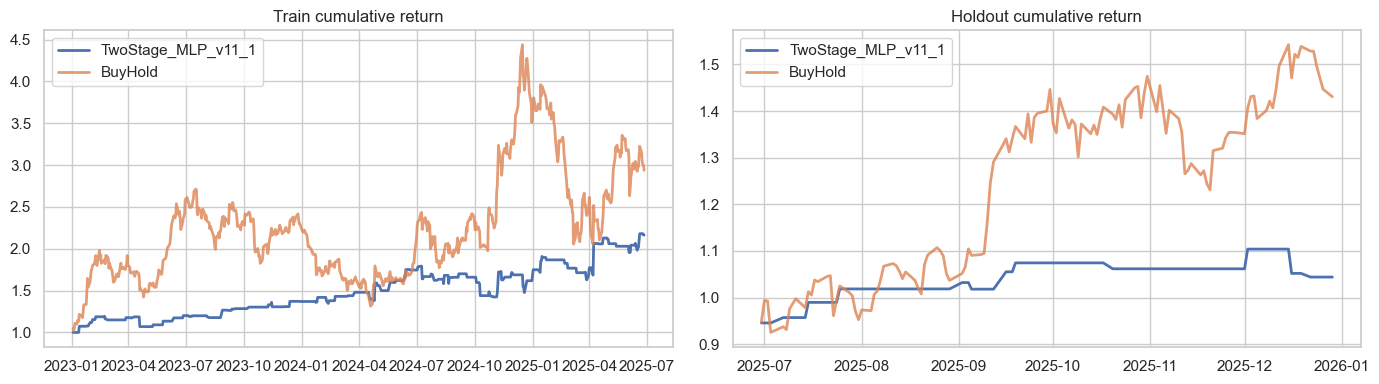

Saved search results to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_v11_1_search_results.csv
Saved rolling results to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_v11_1_rolling_window_results.csv
Saved metrics to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_v11_1_metrics.csv
Saved test predictions to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_v11_1_test_predictions.csv
Saved selected features to C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\data\equity_data\model_data\stock_direction_v11_1_selected_features.csv


In [3]:
search_rows = []
config_counter = 0

print(f"Starting v11.1 rolling search with {configs_per_model} candidates")

for (
    move_band,
    top_k_move,
    top_k_dir,
    hidden_layers,
    alpha_value,
    learning_rate,
    move_prob_thr,
    long_prob_thr,
    short_prob_thr,
    allow_short,
) in product(
    MOVE_BANDS,
    TOP_K_MOVE,
    TOP_K_DIR,
    HIDDEN_CHOICES,
    ALPHA_VALUES,
    LR_VALUES,
    MOVE_PROB_THRESHOLDS,
    LONG_PROB_THRESHOLDS,
    SHORT_PROB_THRESHOLDS,
    ALLOW_SHORT_CHOICES,
):
    config_counter += 1
    print(
        f"[Config {config_counter}/{configs_per_model}] "
        f"move_band={move_band}, top_k_move={top_k_move}, top_k_dir={top_k_dir}, "
        f"hidden={hidden_layers}, alpha={alpha_value}, lr={learning_rate}, "
        f"move_thr={move_prob_thr}, long_thr={long_prob_thr}, short_thr={short_prob_thr}, "
        f"allow_short={allow_short}"
    )

    window_stats = []
    invalid = False

    for window in rolling_windows:
        if window["window_id"] == 1 or window["window_id"] == len(rolling_windows) or window["window_id"] % 5 == 0:
            print(f"  window {window['window_id']}/{len(rolling_windows)}")

        tr = window["train_df"]
        te = window["test_df"]
        bundle = fit_two_stage_bundle(
            train_df=tr,
            move_stability_df=move_stability_df,
            dir_stability_df=dir_stability_df,
            move_band=move_band,
            top_k_move=top_k_move,
            top_k_dir=top_k_dir,
            hidden_layers=hidden_layers,
            alpha_value=alpha_value,
            learning_rate=learning_rate,
        )
        if bundle is None:
            invalid = True
            break

        sig, p_move, p_up = predict_two_stage(
            bundle,
            te,
            move_prob_thr=move_prob_thr,
            long_prob_thr=long_prob_thr,
            short_prob_thr=short_prob_thr,
            allow_short=allow_short,
        )
        strat_ret, trade_mask, sig_exec, true_dir, n_trades = backtest_from_signals(
            te["future_return_1d"].to_numpy(),
            sig,
            ONE_WAY_COST,
        )
        stats = perf_stats(strat_ret, trade_mask, sig_exec, n_trades)
        window_stats.append(stats)

    if invalid or not window_stats:
        print("  no valid rolling result for this config")
        continue

    mean_cum = float(np.mean([s["cum_return"] for s in window_stats]))
    median_cum = float(np.median([s["cum_return"] for s in window_stats]))
    mean_sharpe = float(np.mean([s["sharpe"] for s in window_stats]))
    mean_drawdown = float(np.mean([s["max_drawdown"] for s in window_stats]))
    mean_active = float(np.mean([s["active_pct"] for s in window_stats]))
    hit_values = [s["hit_rate_active"] for s in window_stats if not np.isnan(s["hit_rate_active"])]
    mean_hit = float(np.mean(hit_values)) if hit_values else 0.5
    profitable_pct = float(np.mean([s["cum_return"] > 0 for s in window_stats]))

    score = (
        0.35 * mean_sharpe
        + 0.25 * median_cum
        + 0.15 * (profitable_pct - 0.5)
        + 0.15 * (mean_hit - 0.5)
        - 0.10 * abs(mean_drawdown)
    )
    if mean_active < MIN_ACTIVE_PCT:
        score -= 0.25 * ((MIN_ACTIVE_PCT - mean_active) / MIN_ACTIVE_PCT)

    search_rows.append(
        {
            "move_band": move_band,
            "top_k_move": top_k_move,
            "top_k_dir": top_k_dir,
            "hidden_layers": str(tuple(hidden_layers)),
            "alpha_value": alpha_value,
            "learning_rate": learning_rate,
            "move_prob_thr": move_prob_thr,
            "long_prob_thr": long_prob_thr,
            "short_prob_thr": short_prob_thr,
            "allow_short": bool(allow_short),
            "rolling_score": score,
            "rolling_mean_cum_return": mean_cum,
            "rolling_median_cum_return": median_cum,
            "rolling_mean_sharpe": mean_sharpe,
            "rolling_mean_drawdown": mean_drawdown,
            "rolling_mean_active_pct": mean_active,
            "rolling_mean_hit_rate": mean_hit,
            "rolling_profitable_window_pct": profitable_pct,
            "n_windows": len(window_stats),
        }
    )
    print(
        f"  done: score={score:.4f}, mean_cum={mean_cum:.4f}, "
        f"mean_sharpe={mean_sharpe:.4f}, mean_active={mean_active:.4f}, mean_dd={mean_drawdown:.4f}"
    )

search_df = pd.DataFrame(search_rows).sort_values("rolling_score", ascending=False).reset_index(drop=True)
if search_df.empty:
    raise RuntimeError("No search results generated for v11.1")

search_path = output_dir / "stock_direction_v11_1_search_results.csv"
search_df.to_csv(search_path, index=False)
display(search_df.head(10))

best_cfg = search_df.iloc[0].to_dict()
print("Best v11.1 config:", best_cfg)

print("Re-running best v11.1 config across rolling windows...")
rolling_best_rows = []
for window in rolling_windows:
    if window["window_id"] == 1 or window["window_id"] == len(rolling_windows) or window["window_id"] % 5 == 0:
        print(f"  best-config window {window['window_id']}/{len(rolling_windows)}")

    tr = window["train_df"]
    te = window["test_df"]
    bundle = fit_two_stage_bundle(
        train_df=tr,
        move_stability_df=move_stability_df,
        dir_stability_df=dir_stability_df,
        move_band=float(best_cfg["move_band"]),
        top_k_move=int(best_cfg["top_k_move"]),
        top_k_dir=int(best_cfg["top_k_dir"]),
        hidden_layers=ast.literal_eval(best_cfg["hidden_layers"]),
        alpha_value=float(best_cfg["alpha_value"]),
        learning_rate=float(best_cfg["learning_rate"]),
    )
    sig, p_move, p_up = predict_two_stage(
        bundle,
        te,
        move_prob_thr=float(best_cfg["move_prob_thr"]),
        long_prob_thr=float(best_cfg["long_prob_thr"]),
        short_prob_thr=float(best_cfg["short_prob_thr"]),
        allow_short=bool(best_cfg["allow_short"]),
    )
    strat_ret, trade_mask, sig_exec, true_dir, n_trades = backtest_from_signals(
        te["future_return_1d"].to_numpy(),
        sig,
        ONE_WAY_COST,
    )
    stats = perf_stats(strat_ret, trade_mask, sig_exec, n_trades)
    rolling_best_rows.append(
        {
            "window_id": window["window_id"],
            "train_start": str(window["train_start"].date()),
            "train_end": str(window["train_end"].date()),
            "test_start": str(window["test_start"].date()),
            "test_end": str(window["test_end"].date()),
            "move_rows_train": bundle["move_rows"],
            "move_features_used": len(bundle["move_cols"]),
            "direction_features_used": len(bundle["dir_cols"]),
            **stats,
        }
    )

rolling_best_df = pd.DataFrame(rolling_best_rows)
rolling_path = output_dir / "stock_direction_v11_1_rolling_window_results.csv"
rolling_best_df.to_csv(rolling_path, index=False)
display(rolling_best_df.head(10).round(4))

print("Fitting best v11.1 config on final training split...")
final_bundle = fit_two_stage_bundle(
    train_df=final_train_df,
    move_stability_df=move_stability_df,
    dir_stability_df=dir_stability_df,
    move_band=float(best_cfg["move_band"]),
    top_k_move=int(best_cfg["top_k_move"]),
    top_k_dir=int(best_cfg["top_k_dir"]),
    hidden_layers=ast.literal_eval(best_cfg["hidden_layers"]),
    alpha_value=float(best_cfg["alpha_value"]),
    learning_rate=float(best_cfg["learning_rate"]),
)

print("Scoring final train and holdout splits...")
sig_train, p_move_train, p_up_train = predict_two_stage(
    final_bundle,
    final_train_df,
    move_prob_thr=float(best_cfg["move_prob_thr"]),
    long_prob_thr=float(best_cfg["long_prob_thr"]),
    short_prob_thr=float(best_cfg["short_prob_thr"]),
    allow_short=bool(best_cfg["allow_short"]),
)
sig_test, p_move_test, p_up_test = predict_two_stage(
    final_bundle,
    final_test_df,
    move_prob_thr=float(best_cfg["move_prob_thr"]),
    long_prob_thr=float(best_cfg["long_prob_thr"]),
    short_prob_thr=float(best_cfg["short_prob_thr"]),
    allow_short=bool(best_cfg["allow_short"]),
)

train_strat_ret, train_trade_mask, train_sig_exec, train_true_dir, train_trades = backtest_from_signals(
    final_train_df["future_return_1d"].to_numpy(),
    sig_train,
    ONE_WAY_COST,
)
test_strat_ret, test_trade_mask, test_sig_exec, test_true_dir, test_trades = backtest_from_signals(
    final_test_df["future_return_1d"].to_numpy(),
    sig_test,
    ONE_WAY_COST,
)

buyhold_train = final_train_df.copy()
buyhold_train["signal"] = 1
buyhold_train["strategy_return"] = buyhold_train["future_return_1d"]
buyhold_train["trade_true_dir"] = np.where(buyhold_train["future_return_1d"] > 0, 1.0, 0.0)

buyhold_test = final_test_df.copy()
buyhold_test["signal"] = 1
buyhold_test["strategy_return"] = buyhold_test["future_return_1d"]
buyhold_test["trade_true_dir"] = np.where(buyhold_test["future_return_1d"] > 0, 1.0, 0.0)

metrics_rows = [
    {"model": "BuyHold", "split": "train", **perf_stats(buyhold_train["strategy_return"], np.ones(len(buyhold_train), dtype=bool), np.ones(len(buyhold_train), dtype=int), len(buyhold_train))},
    {"model": "BuyHold", "split": "test", **perf_stats(buyhold_test["strategy_return"], np.ones(len(buyhold_test), dtype=bool), np.ones(len(buyhold_test), dtype=int), len(buyhold_test))},
    {"model": "TwoStage_MLP_v11_1", "split": "train", **perf_stats(train_strat_ret, train_trade_mask, train_sig_exec, train_trades)},
    {"model": "TwoStage_MLP_v11_1", "split": "test", **perf_stats(test_strat_ret, test_trade_mask, test_sig_exec, test_trades)},
]
metrics_df = pd.DataFrame(metrics_rows)
metrics_path = output_dir / "stock_direction_v11_1_metrics.csv"
metrics_df.to_csv(metrics_path, index=False)

test_predictions = final_test_df[["date", "future_return_1d", "y_dir"]].copy()
test_predictions["p_move"] = p_move_test
test_predictions["p_up"] = p_up_test
test_predictions["signal"] = sig_test
test_predictions["trade_executed"] = test_trade_mask
test_predictions["strategy_return"] = test_strat_ret
test_predictions["trade_true_dir"] = test_true_dir
pred_path = output_dir / "stock_direction_v11_1_test_predictions.csv"
test_predictions.to_csv(pred_path, index=False)

selected_feature_rows = []
stability_lookup = feature_stability_df.set_index(["stage", "feature"]) if not feature_stability_df.empty else pd.DataFrame()
for stage_name, cols in [("move", final_bundle["move_cols"]), ("direction", final_bundle["dir_cols"])]:
    for rank, feature in enumerate(cols, start=1):
        row = {
            "stage": stage_name,
            "feature": feature,
            "selected_rank": rank,
            "hidden_layers": best_cfg["hidden_layers"],
            "alpha_value": float(best_cfg["alpha_value"]),
            "learning_rate": float(best_cfg["learning_rate"]),
            "allow_short": bool(best_cfg["allow_short"]),
        }
        if not feature_stability_df.empty and (stage_name, feature) in stability_lookup.index:
            stats = stability_lookup.loc[(stage_name, feature)]
            if isinstance(stats, pd.DataFrame):
                stats = stats.iloc[0]
            row["stability_freq_top_n"] = float(stats["freq_top_n"])
            row["stability_coverage"] = float(stats["coverage"])
            row["stability_mean_rank"] = float(stats["mean_rank"])
            row["stability_mean_mi"] = float(stats["mean_mi"])
        else:
            row["stability_freq_top_n"] = np.nan
            row["stability_coverage"] = np.nan
            row["stability_mean_rank"] = np.nan
            row["stability_mean_mi"] = np.nan
        selected_feature_rows.append(row)

selected_features_df = pd.DataFrame(selected_feature_rows)
selected_features_path = output_dir / "stock_direction_v11_1_selected_features.csv"
selected_features_df.to_csv(selected_features_path, index=False)

display(metrics_df.round(4))
display(selected_features_df)

print("Preparing classification report and plots...")
active_test = test_predictions[test_predictions["signal"] != 0].copy()
if len(active_test):
    y_true_active = active_test["trade_true_dir"].astype(int)
    y_pred_active = np.where(active_test["signal"] == 1, 1, 0)
    print("Classification report on active trades:")
    print(classification_report(y_true_active, y_pred_active, digits=4))
else:
    print("No active trades on the final holdout.")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
train_equity = np.cumprod(1 + train_strat_ret)
test_equity = np.cumprod(1 + test_strat_ret)
buyhold_train_equity = np.cumprod(1 + final_train_df["future_return_1d"].to_numpy())
buyhold_test_equity = np.cumprod(1 + final_test_df["future_return_1d"].to_numpy())

axes[0].plot(final_train_df["date"], train_equity, label="TwoStage_MLP_v11_1", linewidth=2)
axes[0].plot(final_train_df["date"], buyhold_train_equity, label="BuyHold", linewidth=2, alpha=0.8)
axes[0].set_title("Train cumulative return")
axes[0].legend()

axes[1].plot(final_test_df["date"], test_equity, label="TwoStage_MLP_v11_1", linewidth=2)
axes[1].plot(final_test_df["date"], buyhold_test_equity, label="BuyHold", linewidth=2, alpha=0.8)
axes[1].set_title("Holdout cumulative return")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Saved search results to {search_path}")
print(f"Saved rolling results to {rolling_path}")
print(f"Saved metrics to {metrics_path}")
print(f"Saved test predictions to {pred_path}")
print(f"Saved selected features to {selected_features_path}")
